# 04 — Regresión de Edad v4

**Objetivo:** mejorar v3 (MAE ~5.8) enfocando error en extremos de edad y fine-tuning progresivo.

## Cambios principales vs v3

1. **Backbone actualizado**: `backbone_densenet121_v4.keras` (desde clasificación v4).
2. **Formato de guardado moderno**: `.keras` (en lugar de `.h5`).
3. **Ponderación por edad en train** (`sample_weight`) para penalizar más errores en 0–20 y 81–100.
4. **Fine-tuning progresivo en 2 etapas**:
   - Fase 2A: descongelar 80 capas.
   - Fase 2B: descongelar 120 capas con LR más bajo.
5. **Entrenamiento más eficiente para Colab Pro**:
   - Menos epochs “fijos” y más control por callbacks.
   - Early stopping más agresivo.

# Celda 01 - Verificación de GPU

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU encontrada: {gpus[0].name}")
    print("El entrenamiento usará aceleración por GPU.")
else:
    raise SystemError(
        "No se encontró GPU.\n"
        "Ir a: Entorno de ejecución → Cambiar tipo → Acelerador: GPU → Guardar."
    )

GPU encontrada: /physical_device:GPU:0
El entrenamiento usará aceleración por GPU.


# Celda 02 - Montar Drive y rutas

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# ── Raíz del proyecto ─────────────────────────────────────────────────────────
ruta_vena        = Path("/content/drive/MyDrive/Vena")
ruta_checkpoints = ruta_vena / "checkpoints"
ruta_datasets    = ruta_vena / "Notebooks" / "Datasets"

# ── Backbone clasificación v4
ruta_backbone = ruta_checkpoints / "backbone_densenet121_v4.keras"
assert ruta_backbone.exists(), f"No se encontró el backbone: {ruta_backbone}"

# ── Modelo de salida regresión v4
ruta_checkpoints.mkdir(parents=True, exist_ok=True)
ruta_modelo = ruta_checkpoints / "regresion_v4.keras"
ruta_backbone_reg = ruta_checkpoints / "backbone_reg_v4.keras"

# ── ZIP dataset
candidatos_zip = [
    ruta_datasets / "DatasetV2.zip",
    ruta_datasets / "Datasets.zip",
    ruta_datasets / "super_dataset.zip",
]
ruta_super_zip = next((p for p in candidatos_zip if p.exists()), None)
assert ruta_super_zip is not None, (
    f"No se encontró el ZIP del DatasetV2 en {ruta_datasets}\n"
    "Candidatos: DatasetV2.zip | Datasets.zip | super_dataset.zip"
)
ruta_super_local = Path("/content/DatasetV2")

print("Rutas verificadas:")
print(f"  Backbone v4 : {ruta_backbone.exists()} — {ruta_backbone.name}")
print(f"  DatasetV2   : {ruta_super_zip.name}")
print(f"  Salida model: {ruta_modelo.name}")

Mounted at /content/drive
Rutas verificadas:
  Backbone v4 : True — backbone_densenet121_v4.keras
  DatasetV2   : DatasetV2.zip
  Salida model: regresion_v4.keras


# Celda 03 - Imports + parámetros

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess, time
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Mixed precision (acelera en GPU modernas de Colab Pro)
#from tensorflow.keras import mixed_precision
#mixed_precision.set_global_policy("mixed_float16")

# ══ PARÁMETROS v4 ═════════════════════════════════════════════════════════════
MUESTREO_ACTIVO = False
MUESTREO_N      = 5000

TAMANO_IMAGEN = 224
BATCH_SIZE    = 64   # si OOM, usa 32

# Fase 1: cabeza
EPOCHS_FASE1 = 8
LR_FASE1     = 1e-3

# Fase 2A: fine-tuning medio
EPOCHS_FASE2A      = 10
LR_FASE2A          = 1e-4
CAPAS_DESCONGELAR_A = 80

# Fase 2B: fine-tuning más profundo
EPOCHS_FASE2B      = 8
LR_FASE2B          = 5e-5
CAPAS_DESCONGELAR_B = 120

PACIENCIA_EARLY = 4
SEMILLA = 42

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Parámetros v4 cargados.")

Parámetros v4 cargados.


# Celda 04 - Descomprimir DatasetV2

In [4]:
def contar_imagenes(ruta):
    if not ruta.exists():
        return 0
    exts = ("*.jpg", "*.jpeg", "*.png")
    return sum(sum(1 for _ in ruta.rglob(e)) for e in exts)

n_existentes = contar_imagenes(ruta_super_local)

if n_existentes > 5000:
    print(f"DatasetV2 ya en disco local: {n_existentes:,} imágenes. Saltando.")
else:
    print(f"Descomprimiendo {ruta_super_zip.name} ...")
    t0 = time.time()
    res = subprocess.run(f'unzip -q "{ruta_super_zip}" -d /content/', shell=True, capture_output=True)
    if res.returncode != 0:
        print("ERROR:", res.stderr.decode())
    else:
        n = contar_imagenes(ruta_super_local)
        print(f"OK — {n:,} imágenes en {(time.time()-t0)/60:.1f} min")

Descomprimiendo DatasetV2.zip ...
OK — 96,256 imágenes en 0.5 min


# Celda 05 - Cargar masters, limpiar, normalizar + pesos por edad

In [5]:
def cargar_master(nombre_archivo):
    p = ruta_super_local / nombre_archivo
    assert p.exists(), f"No encontrado: {p}"
    df = pd.read_csv(p)
    if "path" in df.columns:
        df["ruta_img"] = df["path"].apply(lambda x: str(ruta_super_local / x))
    elif "ruta_completa" in df.columns:
        df = df.rename(columns={"ruta_completa": "ruta_img"})
    return df

df_train = cargar_master("master_train.csv")
df_val   = cargar_master("master_val.csv")
df_test  = cargar_master("master_test.csv")

for df in [df_train, df_val, df_test]:
    df["edad"] = pd.to_numeric(df["patient_age"], errors="coerce")

def limpiar(df, label):
    antes = len(df)
    df = df[(df["edad"] >= 1) & (df["edad"] <= 100)].copy()
    mask = df["ruta_img"].apply(lambda p: Path(str(p)).exists())
    falt = (~mask).sum()
    df = df[mask].reset_index(drop=True)
    print(f"{label}: {len(df):,} | inválidas: {antes-len(df)-falt} | faltantes: {falt}")
    return df

df_train = limpiar(df_train, "train")
df_val   = limpiar(df_val,   "val")
df_test  = limpiar(df_test,  "test")

# Normalización edad
scaler_edad = StandardScaler()
df_train["edad_norm"] = scaler_edad.fit_transform(df_train[["edad"]])
df_val["edad_norm"]   = scaler_edad.transform(df_val[["edad"]])
df_test["edad_norm"]  = scaler_edad.transform(df_test[["edad"]])

edad_media = float(scaler_edad.mean_[0])
edad_std   = float(scaler_edad.scale_[0])
baseline_mae = (df_train["edad"] - edad_media).abs().mean()

# CAMBIO v4: pesos por edad para mejorar extremos
def peso_por_edad(e):
    if e <= 20: return 1.35
    if e <= 40: return 1.00
    if e <= 60: return 0.95
    if e <= 80: return 1.10
    return 1.60

df_train["sample_weight"] = df_train["edad"].apply(peso_por_edad).astype("float32")

df_train["sample_weight"] = df_train["sample_weight"] / df_train["sample_weight"].mean()

df_val["sample_weight"] = 1.0
df_test["sample_weight"] = 1.0

print(f"Media: {edad_media:.1f} | Std: {edad_std:.1f} | Baseline MAE: {baseline_mae:.2f}")

train: 67,031 | inválidas: 0 | faltantes: 0
val: 14,541 | inválidas: 0 | faltantes: 0
test: 14,684 | inválidas: 0 | faltantes: 0
Media: 50.3 | Std: 17.1 | Baseline MAE: 13.87


# Celda 06 - Generadores (Cambio: weight_col)

In [6]:
gen_train = ImageDataGenerator(
    preprocessing_function=lambda x: x/255.0,
    rotation_range=10,
    zoom_range=0.10,
    horizontal_flip=True,
    width_shift_range=0.08,
    height_shift_range=0.05,
    fill_mode="nearest"
)

gen_eval = ImageDataGenerator(preprocessing_function=lambda x: x/255.0)

def crear_flujo(gen, df, mezclar=True):
    return gen.flow_from_dataframe(
        dataframe=df,
        x_col="ruta_img",
        y_col="edad_norm",
        weight_col="sample_weight" if "sample_weight" in df.columns else None,
        target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
        color_mode="rgb",
        class_mode="raw",
        batch_size=BATCH_SIZE,
        shuffle=mezclar,
        seed=SEMILLA
    )

flujo_train = crear_flujo(gen_train, df_train, True)
flujo_val   = crear_flujo(gen_eval,  df_val,   False)
flujo_test  = crear_flujo(gen_eval,  df_test,  False)

Found 67031 validated image filenames.
Found 14541 validated image filenames.
Found 14684 validated image filenames.


# Celda 07 - Modelo v4

In [7]:
backbone = load_model(str(ruta_backbone), compile=False)
backbone.trainable = False

x = backbone.output
if len(x.shape) == 4:
    x = GlobalAveragePooling2D(name="pool_reg")(x)

x = Dense(512, activation="relu", name="dense_1")(x)
x = BatchNormalization(name="bn_1")(x)
x = Dropout(0.4, name="drop_1")(x)

x = Dense(256, activation="relu", name="dense_2")(x)
x = BatchNormalization(name="bn_2")(x)
x = Dropout(0.3, name="drop_2")(x)

# En mixed precision, salida float32 para estabilidad numérica en regresión
salida = Dense(1, activation="linear", dtype="float32", name="edad_pred")(x)

modelo = Model(inputs=backbone.input, outputs=salida, name="regresion_v4")

modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE1),
    loss=tf.keras.losses.Huber(delta=1.5),
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)
print("Modelo v4 listo.")

Modelo v4 listo.


In [8]:
import time, math
import tensorflow as tf

class ETACallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        total_epochs = self.params.get("epochs", 0)
        done = epoch + 1
        left = max(total_epochs - done, 0)
        eta_sec = left * epoch_time

        def fmt(sec):
            h = int(sec // 3600); m = int((sec % 3600)//60); s = int(sec % 60)
            return f"{h:02d}:{m:02d}:{s:02d}"

        print(f"[ETA] Epoch {done}/{total_epochs} | "
              f"epoch={fmt(epoch_time)} | restante≈{fmt(eta_sec)}")

# Celda 08 - Callbacks

In [9]:
cb_ckpt = ModelCheckpoint(
    filepath=str(ruta_modelo),
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

cb_early = EarlyStopping(
    monitor="val_mae",
    patience=PACIENCIA_EARLY,
    restore_best_weights=True,
    verbose=1
)

cb_lr = ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
cb_eta = ETACallback()
callbacks = [cb_ckpt, cb_early, cb_lr, cb_eta]

# Celda 09 - Fase 1

In [10]:
hist_f1 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE1,
    validation_data=flujo_val,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.5133 - mae: 0.7946 - rmse: 1.0338
Epoch 1: val_mae improved from None to 0.58492, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras
[ETA] Epoch 1/8 | epoch=00:07:55 | restante≈00:55:28
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 475s 433ms/step - loss: 0.3470 - mae: 0.6431 - rmse: 0.8378 - val_loss: 0.2656 - val_mae: 0.5849 - val_rmse: 0.7324 - learning_rate: 0.0010
Epoch 2/8
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 0.2444 - mae: 0.5430 - rmse: 0.6865
Epoch 2: val_mae improved from 0.58492 to 0.52051, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras
[ETA] Epoch 2/8 | epoch=00:07:12 | restante≈00:43:17
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 433s 413ms/step - loss: 0.2414 - mae: 0.5390 - rmse: 0.68

# Celda 10 - Fase 2A (80 capas)

In [11]:
total_capas = len(backbone.layers)
backbone.trainable = True
for i, capa in enumerate(backbone.layers):
    capa.trainable = (i >= total_capas - CAPAS_DESCONGELAR_A)

modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE2A),
    loss=tf.keras.losses.Huber(delta=1.5),
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

hist_f2a = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE2A,
    validation_data=flujo_val,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 0.1836 - mae: 0.4684 - rmse: 0.5966
Epoch 1: val_mae improved from 0.48367 to 0.40008, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras
[ETA] Epoch 1/10 | epoch=00:07:55 | restante≈01:11:17
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 475s 426ms/step - loss: 0.1668 - mae: 0.4462 - rmse: 0.5696 - val_loss: 0.1305 - val_mae: 0.4001 - val_rmse: 0.5118 - learning_rate: 1.0000e-04
Epoch 2/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.1352 - mae: 0.4032 - rmse: 0.5142
Epoch 2: val_mae improved from 0.40008 to 0.38008, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v4.keras
[ETA] Epoch 2/10 | epoch=00:06:55 | restante≈00:55:25
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 416s 397ms/step - loss: 0.1332 - mae: 0.4007 -

# Celda 11 - Fase 2B (120 capas, LR menor)

In [12]:
for i, capa in enumerate(backbone.layers):
    capa.trainable = (i >= total_capas - CAPAS_DESCONGELAR_B)

modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE2B),
    loss=tf.keras.losses.Huber(delta=1.5),
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

hist_f2b = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE2B,
    validation_data=flujo_val,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - loss: 0.0954 - mae: 0.3421 - rmse: 0.4335
Epoch 1: val_mae did not improve from 0.33711
[ETA] Epoch 1/8 | epoch=00:07:56 | restante≈00:55:32
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 476s 422ms/step - loss: 0.0934 - mae: 0.3371 - rmse: 0.4288 - val_loss: 0.0940 - val_mae: 0.3377 - val_rmse: 0.4344 - learning_rate: 5.0000e-05
Epoch 2/8
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0868 - mae: 0.3263 - rmse: 0.4140
Epoch 2: val_mae did not improve from 0.33711

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
[ETA] Epoch 2/8 | epoch=00:06:56 | restante≈00:41:37
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 416s 397ms/step - loss: 0.0863 - mae: 0.3253 - rmse: 0.4129 - val_loss: 0.0952 - val_mae: 0.3379 - val_rmse: 0.4370 - learning_rate: 5.0000e-05
Epoch 3/8
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 0.0793 - mae: 0.3128 - rmse: 0.3963
Epoch 3: val_mae improved from 0.33711 to 0.33674, saving model to /content/dr

In [13]:
# ── Fase 2C: Pulido global extremo ──
# Bajamos el umbral para asegurar que se ejecute si la mejora fue marginal

#UMBRAL_MEJORA = 0.025
#EPOCHS_FASE2C = 5
#LR_FASE2C = 1e-6  # <--- Un orden de magnitud menor para estabilidad total

#val_mae_f2b = hist_f2b.history.get("val_mae", [])
#mejora_f2b = val_mae_f2b[0] - min(val_mae_f2b) if len(val_mae_f2b) >= 2 else 0.0

#print(f"Mejora en Fase 2B: {mejora_f2b:.4f}")

#if mejora_f2b < UMBRAL_MEJORA:
 #   print(f"🔎 Activando Fase 2C con LR={LR_FASE2C} para romper la barrera de los 4 años...")

    # IMPORTANTE: Asegúrate de que el modelo sea totalmente entrenable antes de compilar
  #  modelo.trainable = True

   # modelo.compile(
    #    optimizer=Adam(learning_rate=LR_FASE2C),
     #   loss=tf.keras.losses.Huber(delta=1.5),
      #  metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    #)

    #hist_f2c = modelo.fit(
     #   flujo_train,
      #  epochs=EPOCHS_FASE2C,
       # validation_data=flujo_val,
        #callbacks=callbacks, # El EarlyStopping y CSVLogger que agregamos seguirán funcionando
        #verbose=1
    #)
#else:
 #   print("✅ La Fase 2B fue suficiente. Saltando a evaluación final.")
  #  hist_f2c = None

Mejora observada en Fase 2B (val_mae norm): 0.0140
🔎 Mejora baja en F2B -> activando Fase 2C (LR=1e-5) para pulido fino...
Epoch 1/5
 163/1048 ━━━━━━━━━━━━━━━━━━━━ 5:43 388ms/step - loss: 0.0701 - mae: 0.2940 - rmse: 0.3727

KeyboardInterrupt: 

# Celda 12 - Evaluación test

In [14]:
mejor = load_model(str(ruta_modelo), compile=False)
mejor.compile(optimizer="adam",
              loss=tf.keras.losses.Huber(delta=1.5),
              metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])

flujo_test.reset()
pred_norm = mejor.predict(flujo_test, verbose=1).reshape(-1)
pred_norm = pred_norm[:len(df_test)]

pred_anios = scaler_edad.inverse_transform(pred_norm.reshape(-1,1)).flatten()
real_anios = df_test["edad"].values
pred_anios = np.clip(pred_anios, 1, 110)

mae  = np.mean(np.abs(pred_anios - real_anios))
rmse = np.sqrt(np.mean((pred_anios - real_anios)**2))
r2   = r2_score(real_anios, pred_anios)

print(f"MAE: {mae:.2f} años")
print(f"RMSE: {rmse:.2f} años")
print(f"R2: {r2:.3f}")

230/230 ━━━━━━━━━━━━━━━━━━━━ 32s 106ms/step
MAE: 5.61 años
RMSE: 7.24 años
R2: 0.822


# Celda 13 - Guardar backbone fine-tuneado

In [15]:
capa_pool = next((l for l in modelo.layers if "pool" in l.name or "global" in l.name.lower()), None)

if capa_pool:
    backbone_reg = Model(inputs=modelo.input, outputs=capa_pool.output, name="backbone_reg_v4")
    backbone_reg.save(str(ruta_backbone_reg))
    print(f"Backbone guardado: {ruta_backbone_reg}")
else:
    print("No se encontró capa pool.")

Backbone guardado: /content/drive/MyDrive/Vena/checkpoints/backbone_reg_v4.keras


Guardada: /content/drive/MyDrive/Vena/checkpoints/curvas_regresion_v4.png


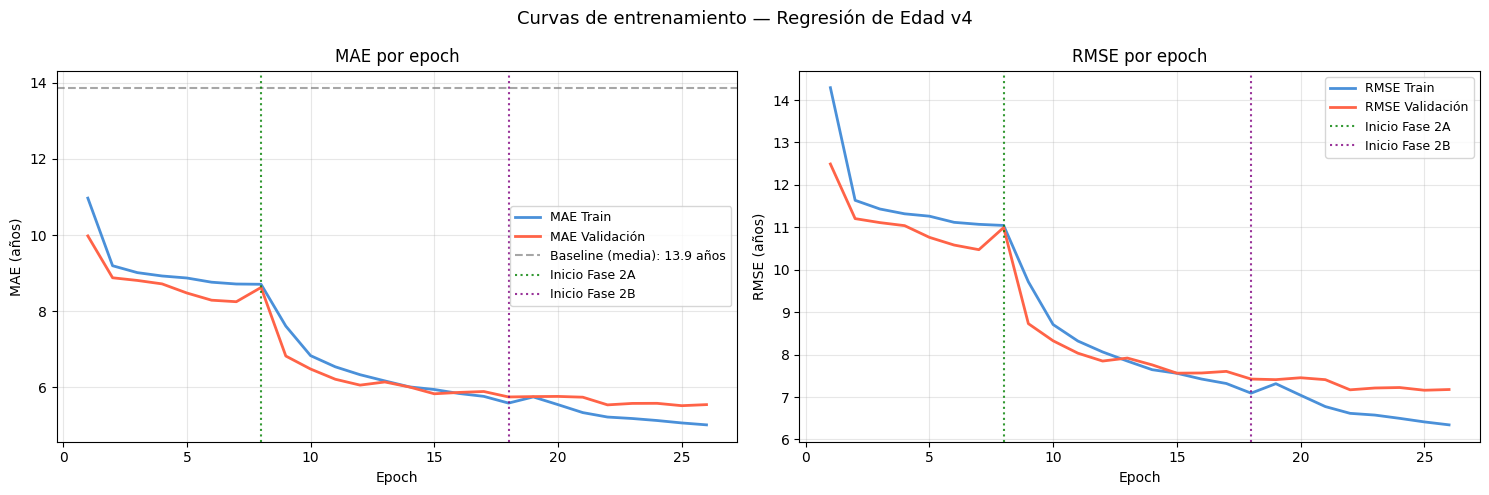

In [16]:
# ══ Curvas de entrenamiento — v4 (Fase 1 + 2A + 2B) ══════════════════════════

mae_tr  = hist_f1.history["mae"]      + hist_f2a.history["mae"]      + hist_f2b.history["mae"]
mae_va  = hist_f1.history["val_mae"]  + hist_f2a.history["val_mae"]  + hist_f2b.history["val_mae"]
rmse_tr = hist_f1.history["rmse"]     + hist_f2a.history["rmse"]     + hist_f2b.history["rmse"]
rmse_va = hist_f1.history["val_rmse"] + hist_f2a.history["val_rmse"] + hist_f2b.history["val_rmse"]

# Desnormalizar a años reales
mae_tr_a  = [m * edad_std for m in mae_tr]
mae_va_a  = [m * edad_std for m in mae_va]
rmse_tr_a = [m * edad_std for m in rmse_tr]
rmse_va_a = [m * edad_std for m in rmse_va]

epochs   = range(1, len(mae_tr) + 1)
fin_f1   = len(hist_f1.history["mae"])
fin_f2a  = fin_f1 + len(hist_f2a.history["mae"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# MAE
ax1.plot(epochs, mae_tr_a,  label="MAE Train",      linewidth=2, color="#4A90D9")
ax1.plot(epochs, mae_va_a,  label="MAE Validación",  linewidth=2, color="tomato")
ax1.axhline(baseline_mae, color="gray", linestyle="--", alpha=0.7,
            label=f"Baseline (media): {baseline_mae:.1f} años")
ax1.axvline(fin_f1,  color="green",  linestyle=":", alpha=0.8, label="Inicio Fase 2A")
ax1.axvline(fin_f2a, color="purple", linestyle=":", alpha=0.8, label="Inicio Fase 2B")
ax1.set_title("MAE por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MAE (años)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# RMSE
ax2.plot(epochs, rmse_tr_a, label="RMSE Train",      linewidth=2, color="#4A90D9")
ax2.plot(epochs, rmse_va_a, label="RMSE Validación",  linewidth=2, color="tomato")
ax2.axvline(fin_f1,  color="green",  linestyle=":", alpha=0.8, label="Inicio Fase 2A")
ax2.axvline(fin_f2a, color="purple", linestyle=":", alpha=0.8, label="Inicio Fase 2B")
ax2.set_title("RMSE por epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (años)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — Regresión de Edad v4", fontsize=13)
plt.tight_layout()
ruta_curvas = ruta_checkpoints / "curvas_regresion_v4.png"
plt.savefig(str(ruta_curvas), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_curvas}")
plt.show()

Guardada: /content/drive/MyDrive/Vena/checkpoints/evaluacion_regresion_v4.png


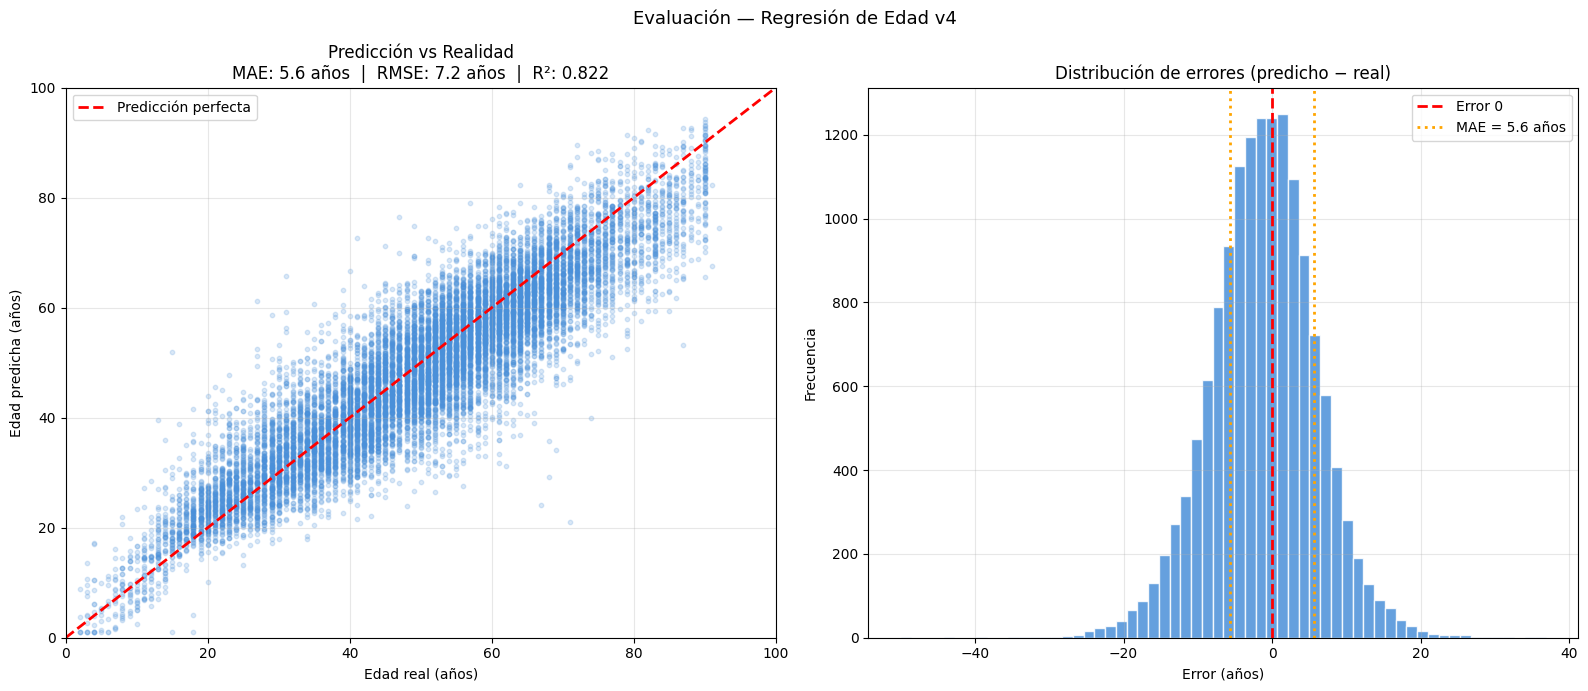


═════════════════════════════════════════════
COMPARATIVA v2 → v4
  MAE  : 5.80 → 5.61 años  (+3.3%)
  RMSE : 7.40 → 7.24 años  (+2.2%)
  R²   : 0.813 → 0.822          (+1.2%)
═════════════════════════════════════════════


In [17]:
# ══ Scatter y histograma de errores ══════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: predicho vs real
ax1.scatter(real_anios, pred_anios, alpha=0.2, s=10, color="#4A90D9")
lim = [0, 100]
ax1.plot(lim, lim, "r--", linewidth=2, label="Predicción perfecta")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("Edad real (años)")
ax1.set_ylabel("Edad predicha (años)")
ax1.set_title(
    f"Predicción vs Realidad\n"
    f"MAE: {mae:.1f} años  |  RMSE: {rmse:.1f} años  |  R²: {r2:.3f}"
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histograma de errores
errores = pred_anios - real_anios
ax2.hist(errores, bins=60, color="#4A90D9", alpha=0.85, edgecolor="white")
ax2.axvline(0,    color="red",    linestyle="--", linewidth=2, label="Error 0")
ax2.axvline( mae, color="orange", linestyle=":",  linewidth=2, label=f"MAE = {mae:.1f} años")
ax2.axvline(-mae, color="orange", linestyle=":",  linewidth=2)
ax2.set_title("Distribución de errores (predicho − real)")
ax2.set_xlabel("Error (años)")
ax2.set_ylabel("Frecuencia")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Evaluación — Regresión de Edad v4", fontsize=13)
plt.tight_layout()
ruta_eval = ruta_checkpoints / "evaluacion_regresion_v4.png"
plt.savefig(str(ruta_eval), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_eval}")
plt.show()

# Comparativa con v2
print(f"\n{'═'*45}")
print("COMPARATIVA v2 → v4")
print(f"  MAE  : 5.80 → {mae:.2f} años  ({((5.80-mae)/5.80*100):+.1f}%)")
print(f"  RMSE : 7.40 → {rmse:.2f} años  ({((7.40-rmse)/7.40*100):+.1f}%)")
print(f"  R²   : 0.813 → {r2:.3f}          ({((r2-0.813)/0.813*100):+.1f}%)")
print(f"{'═'*45}")

Guardada: /content/drive/MyDrive/Vena/checkpoints/mae_por_rango_v4.png


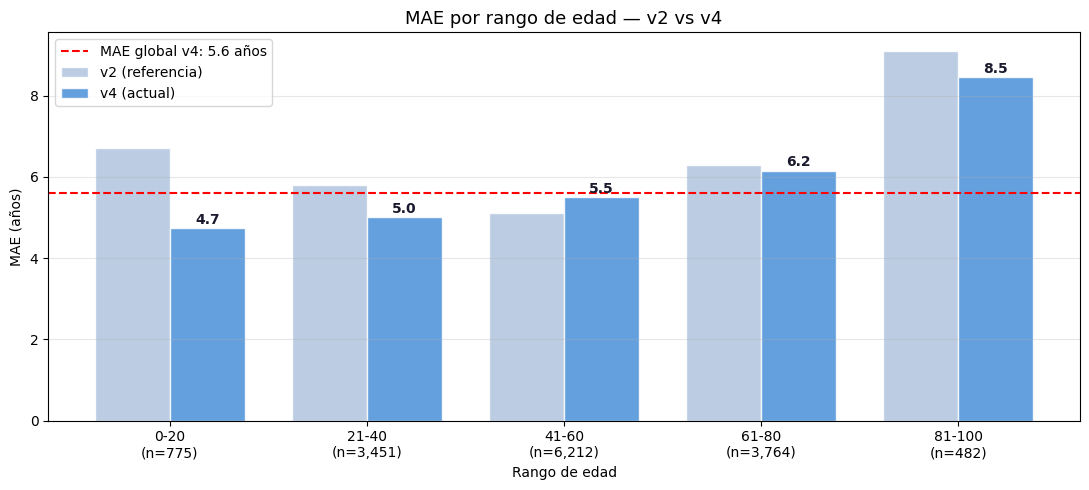

In [18]:
# ══ MAE por rango de edad ═════════════════════════════════════════════════════

rangos = [(1,20,"0-20"), (21,40,"21-40"), (41,60,"41-60"),
          (61,80,"61-80"), (81,100,"81-100")]

# v2 referencia para comparar
mae_v2 = {"0-20":6.7, "21-40":5.8, "41-60":5.1, "61-80":6.3, "81-100":9.1}

mae_v4_rango = []
etiquetas    = []

for lo, hi, label in rangos:
    mask = (real_anios >= lo) & (real_anios <= hi)
    if mask.sum() > 0:
        mae_r = np.mean(np.abs(pred_anios[mask] - real_anios[mask]))
        mae_v4_rango.append(mae_r)
        etiquetas.append(f"{label}\n(n={mask.sum():,})")

fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(len(etiquetas))
ancho = 0.38

bars_v2 = ax.bar(x - ancho/2,
                 [mae_v2[r[2]] for r in rangos],
                 ancho, label="v2 (referencia)",
                 color="#B0C4DE", alpha=0.85, edgecolor="white")

bars_v4 = ax.bar(x + ancho/2,
                 mae_v4_rango,
                 ancho, label="v4 (actual)",
                 color="#4A90D9", alpha=0.85, edgecolor="white")

ax.axhline(mae, color="red", linestyle="--", linewidth=1.5,
           label=f"MAE global v4: {mae:.1f} años")

# Etiquetas encima de las barras
for bar, val in zip(bars_v4, mae_v4_rango):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", fontsize=10, fontweight="bold", color="#1a1a2e")

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_title("MAE por rango de edad — v2 vs v4", fontsize=13)
ax.set_xlabel("Rango de edad")
ax.set_ylabel("MAE (años)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
ruta_rango = ruta_checkpoints / "mae_por_rango_v4.png"
plt.savefig(str(ruta_rango), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_rango}")
plt.show()

Guardada: /content/drive/MyDrive/Vena/checkpoints/visualizacion_regresion_v4.png


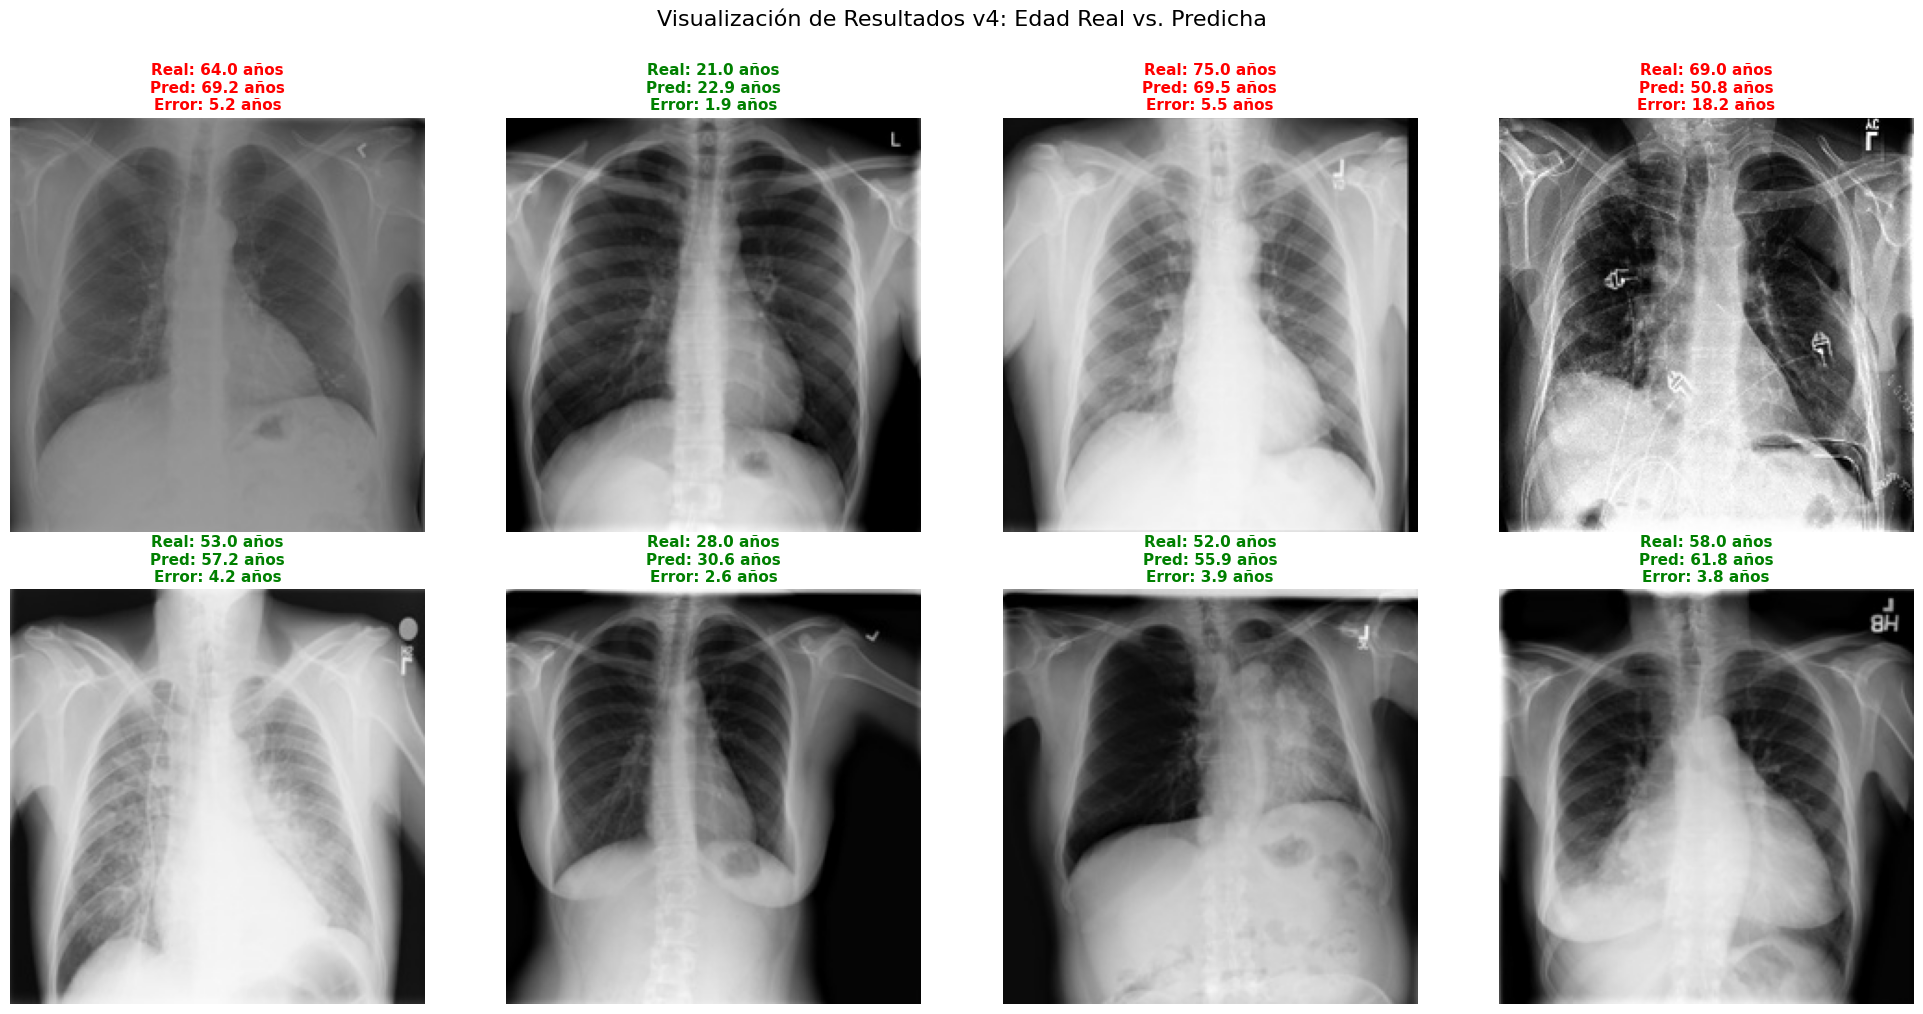

In [19]:
# ══ Visualización de ejemplos ═════════════════════════════════════════════════
import cv2

n_ejemplos = 8
np.random.seed(99)
indices = np.random.choice(len(df_test), n_ejemplos, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    ruta = df_test.iloc[idx]["ruta_img"]
    real = df_test.iloc[idx]["edad"]
    pred = pred_anios[idx]
    error = abs(real - pred)

    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    color = "green" if error < 5 else "red"
    axes[i].set_title(
        f"Real: {real:.1f} años\nPred: {pred:.1f} años\nError: {error:.1f} años",
        color=color, fontsize=11, fontweight="bold"
    )
    axes[i].axis("off")

plt.suptitle("Visualización de Resultados v4: Edad Real vs. Predicha",
             fontsize=16, y=1.01)
plt.tight_layout()
ruta_viz = ruta_checkpoints / "visualizacion_regresion_v4.png"
plt.savefig(str(ruta_viz), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_viz}")
plt.show()

Guardada: /content/drive/MyDrive/Vena/checkpoints/visualizacion_regresion_v4_1.png


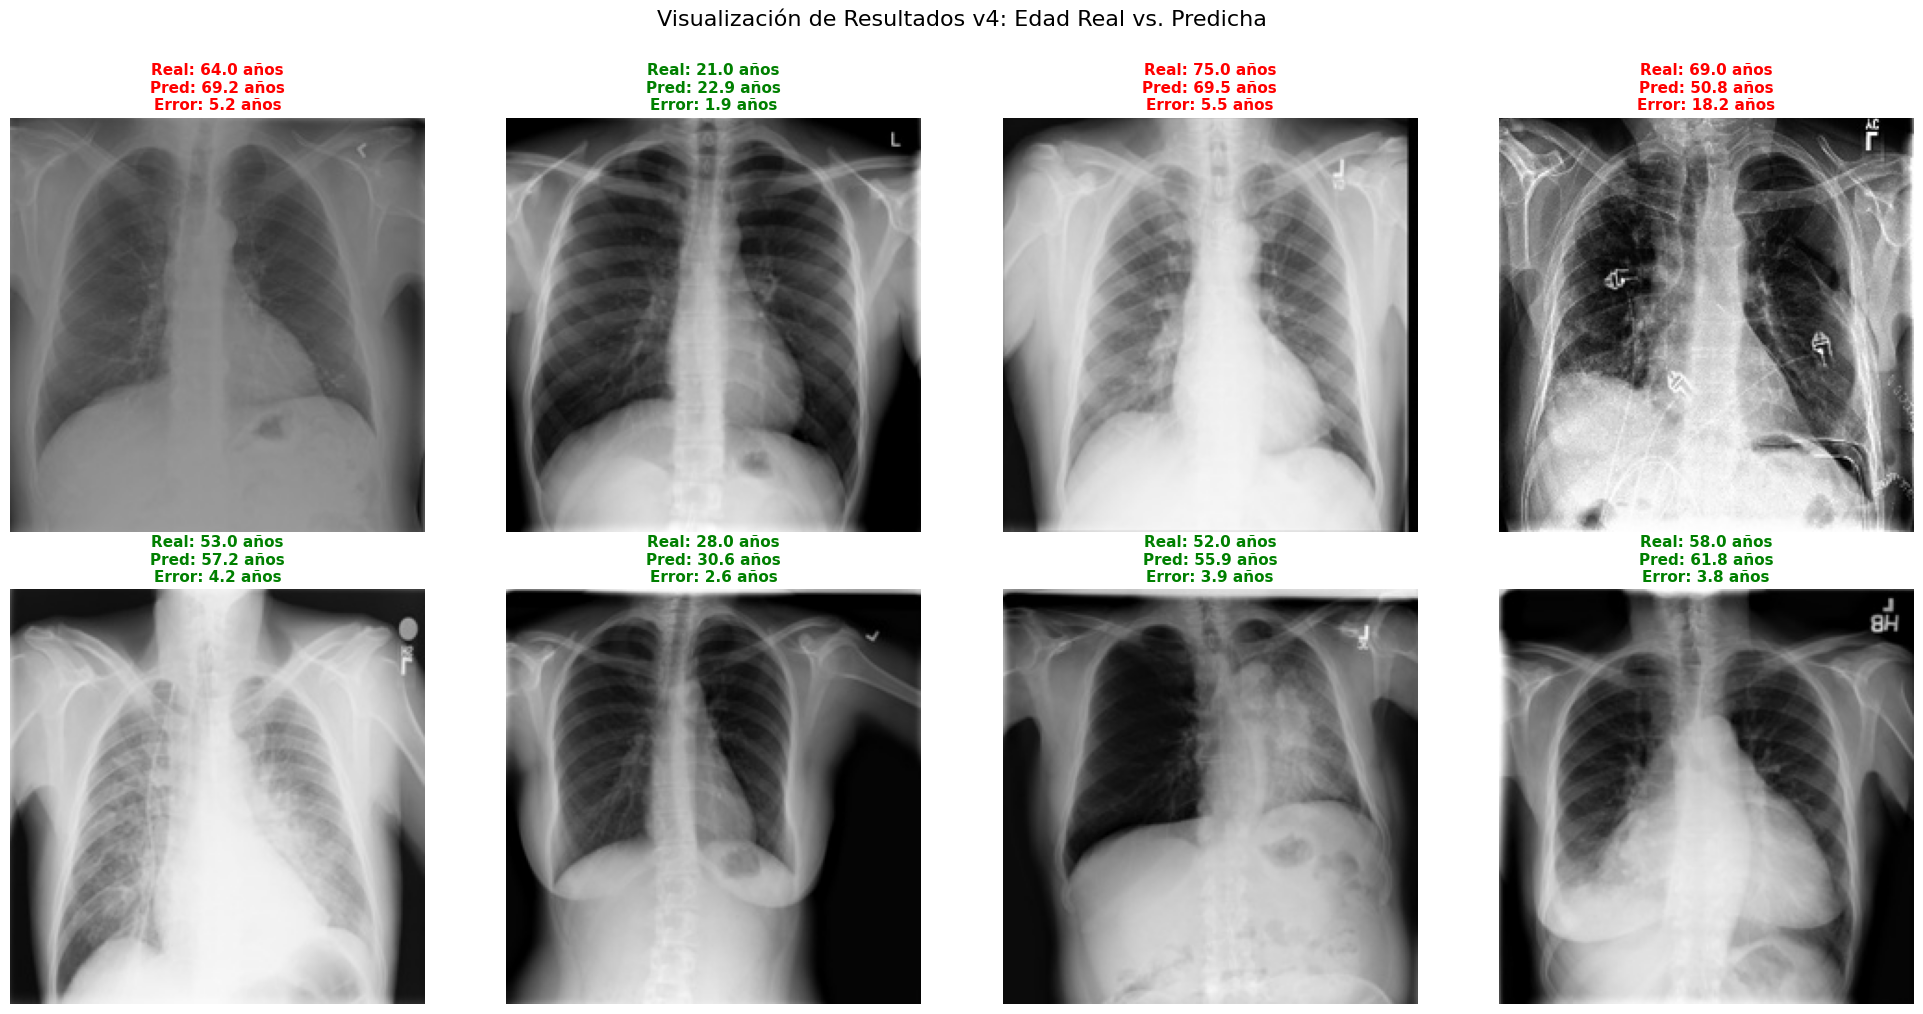

In [20]:
# ══ Visualización de ejemplos ═════════════════════════════════════════════════
import cv2

n_ejemplos = 8
np.random.seed(99)
indices = np.random.choice(len(df_test), n_ejemplos, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    ruta = df_test.iloc[idx]["ruta_img"]
    real = df_test.iloc[idx]["edad"]
    pred = pred_anios[idx]
    error = abs(real - pred)

    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    color = "green" if error < 5 else "red"
    axes[i].set_title(
        f"Real: {real:.1f} años\nPred: {pred:.1f} años\nError: {error:.1f} años",
        color=color, fontsize=11, fontweight="bold"
    )
    axes[i].axis("off")

plt.suptitle("Visualización de Resultados v4: Edad Real vs. Predicha",
             fontsize=16, y=1.01)
plt.tight_layout()
ruta_viz = ruta_checkpoints / "visualizacion_regresion_v4_1.png"
plt.savefig(str(ruta_viz), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_viz}")
plt.show()

Guardada: /content/drive/MyDrive/Vena/checkpoints/visualizacion_regresion_v4_2.png


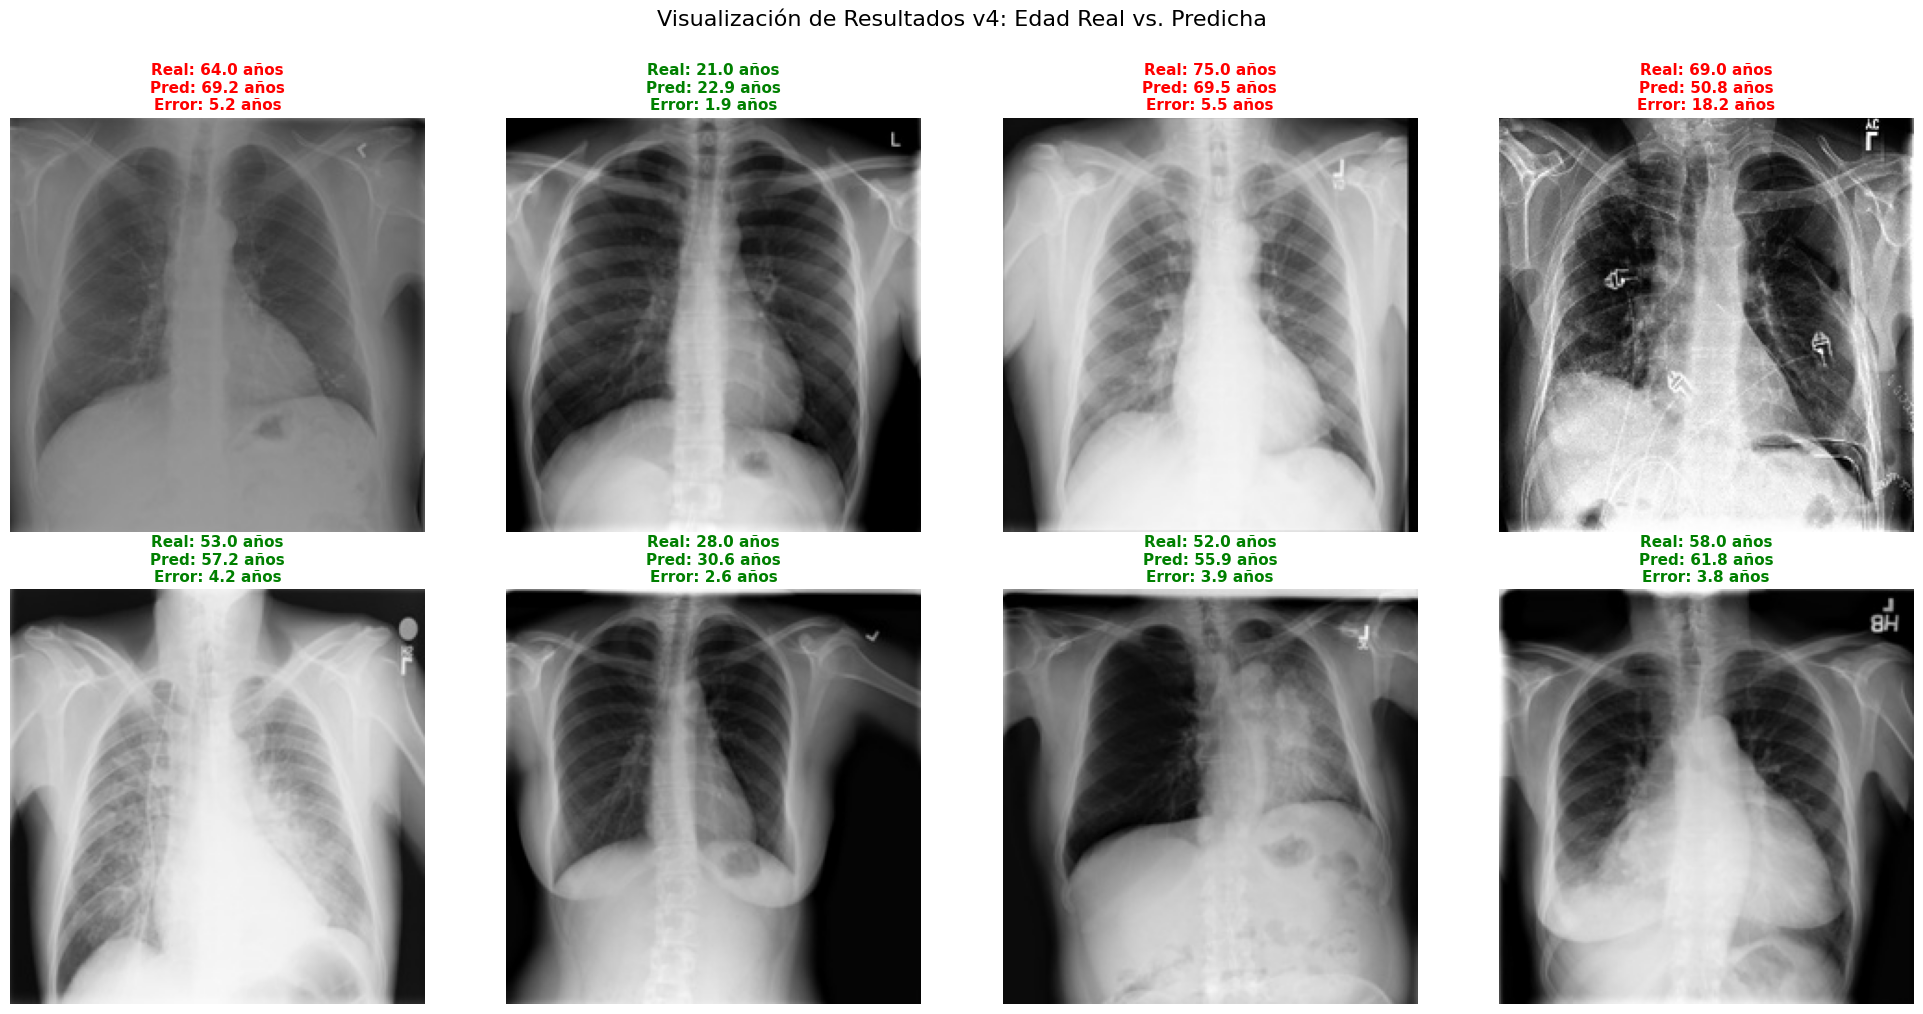

In [21]:
# ══ Visualización de ejemplos ═════════════════════════════════════════════════
import cv2

n_ejemplos = 8
np.random.seed(99)
indices = np.random.choice(len(df_test), n_ejemplos, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    ruta = df_test.iloc[idx]["ruta_img"]
    real = df_test.iloc[idx]["edad"]
    pred = pred_anios[idx]
    error = abs(real - pred)

    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    color = "green" if error < 5 else "red"
    axes[i].set_title(
        f"Real: {real:.1f} años\nPred: {pred:.1f} años\nError: {error:.1f} años",
        color=color, fontsize=11, fontweight="bold"
    )
    axes[i].axis("off")

plt.suptitle("Visualización de Resultados v4: Edad Real vs. Predicha",
             fontsize=16, y=1.01)
plt.tight_layout()
ruta_viz = ruta_checkpoints / "visualizacion_regresion_v4_2.png"
plt.savefig(str(ruta_viz), dpi=150, bbox_inches="tight")
print(f"Guardada: {ruta_viz}")
plt.show()